<a href="https://colab.research.google.com/github/montagnaflor/Prod-Mis-Finanzas/blob/main/Flor_V1_(Entrega_4)_feature_a_estrenar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Base para el Trabajo Práctico (Entrega 3)

Programa de creación de la entrega 3

In [ ]:
import pandas as pd
import sqlite3
import numpy as np

import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# 0. Lectura de datos

In [ ]:
# TODO: Cambiar para que apunte al directorio correcto
DIR = "/content/drive/MyDrive/Maestría Data Mining/Data Mining - Materia/Competencia Kaggle/Metadata"

In [ ]:
engine = sqlite3.connect(f"{DIR}/entrenamiento.db")

df_ent = pd.read_sql("SELECT * FROM entrenamiento", engine, index_col='id')

In [ ]:
# cantidad de filas y columnas
df_ent.shape

(1292674, 17)

In [ ]:
df_ent.columns

Index(['description', 'address', 'lat', 'lon', 'publication_date',
       'publisher_id', 'features', 'location_0', 'location_1', 'location_2',
       'location_3', 'location_4', 'operation_type', 'property_type', 'source',
       'price', 'currency_type'],
      dtype='object')

# 1. Entender los datos (AID)

In [ ]:
# Ver las columnas de ubicación
print("Location columns disponibles:")
print(df_ent[["location_0", "location_1", "location_2", "location_3", "location_4"]].head(20))

print("\n" + "="*80)
print("Valores únicos en location_2:")
print(df_ent["location_2"].value_counts(dropna=False).head(20))

print("\n" + "="*80)
print("Valores únicos en location_3:")
print(df_ent["location_3"].value_counts(dropna=False).head(20))

**Análisis de las columnas de ubicación:**

**Estructura:**

location_2: Mezcla de "Capital Federal", "Buenos Aires" Y algunos barrios (Palermo, Caballito, etc.)
location_3: Mezcla de "Ciudad Autónoma de Buenos Aires", "Ciudad de Buenos Aires", NaN Y barrios

**Estrategia para extraer barrio:**
El barrio puede estar en location_2 O en location_3. Hay que consolidar:

In [ ]:
# 1. Ver cuántos NaN tenés en cada feature
print("NaN en X (train):")
print(X.isna().sum().sort_values(ascending=False))

print("\n" + "="*80)
print("% de filas con AL MENOS 1 NaN:")
filas_con_nan = X.isna().any(axis=1).sum()
print(f"{filas_con_nan} / {len(X)} = {(filas_con_nan/len(X)*100):.2f}%")

print("\n" + "="*80)
print("Features con más de 30% NaN:")
print(X.isna().mean()[X.isna().mean() > 0.3].sort_values(ascending=False))

# 2. Limpiar y transformar los datos (DM)

## 2.1. Filtrado de datos



In [ ]:
caba_values = ["Capital Federal", "Ciudad Autónoma de Buenos Aires", "CABA"]
tipos_validos = ["departamento", "casa", "departamentos", "casas"]

df_ent = df_ent.loc[
    (df_ent["location_0"] == "Argentina") &
    (df_ent["currency_type"] == "dolares") &
    (df_ent["location_1"].isin(caba_values)) &
    (df_ent["operation_type"] == "venta") &
    (df_ent["property_type"].fillna("").str.lower().str.strip().isin(tipos_validos)) &
    (df_ent["price"].notna()) &
    (df_ent["price"] > 1000) &
    (df_ent["price"] < 1.111111e+08)
].copy()

# Homogeneizar property_type
df_ent["property_type"] = df_ent["property_type"].replace({
    "departamentos": "departamento",
    "casas": "casa"
})

print(f"df_ent filtrado: {df_ent.shape}")

df_ent filtrado: (110761, 17)


## 2.4. Creación de nuevos atributos

In [ ]:
# Trabajar con features + description

texto = (
    df_ent["features"].fillna("").astype(str) + " " +
    df_ent["description"].fillna("").astype(str)
)

# función para extraer números
def extraer(patron):
    return pd.to_numeric(texto.str.extract(patron, expand=False), errors="coerce")

# Dormitorios - capturar TODAS las variantes
df_ent["dormitorios"] = extraer(
    r"(\d+)\s*(?:dormitorios?|dormi|habitaciones?|habitacion|habitaci|recamaras?|recamara|cuartos?|habs?\.?|bedrooms?)"
)

# Baños - capturar TODAS las variantes
df_ent["banos"] = extraer(
    r"(\d+)\s*(?:baños?|banos?|baths?|bathrooms?|toilettes?|wc|servicios?)"
)

# Ambientes - capturar TODAS las variantes
df_ent["ambientes"] = extraer(
    r"(\d+)\s*(?:ambientes?|ambiente|amb\.?|ambs?|rooms?|room|environments?)"
)

# 3. Extraer superficies
# Primero: cualquier m² (captura el más común)
df_ent["sup_total"] = extraer(r"(\d+(?:[.,]\d+)?)\s*m[²2]")

# Después: solo cuando dice explícitamente "cubierto/a/s"
df_ent["sup_cubierta"] = extraer(
    r"(?:superficie\s+)?(?:s?cubiert[oa]s?)\s*:?\s*(\d+(?:[.,]\d+)?)"
)






In [ ]:
# Para ver cómo quedaron las extracciones
print("Dormitorios:")
print(df_ent["dormitorios"].value_counts(dropna=False).head(10))

print("\nBaños:")
print(df_ent["banos"].value_counts(dropna=False).head(10))

print("\nAmbientes:")
print(df_ent["ambientes"].value_counts(dropna=False).head(10))

print("\nsup_cubierta:")
print(df_ent["sup_cubierta"].describe())

print("\nsup_total:")
print(df_ent["sup_total"].describe())





Dormitorios:
dormitorios
NaN     31642
1.0     31228
2.0     25187
3.0     16770
4.0      4202
5.0       996
6.0       334
7.0       133
8.0        47
13.0       35
Name: count, dtype: int64

Baños:
banos
1.0    61088
NaN    20750
2.0    20571
3.0     5902
4.0     1685
5.0      495
6.0      101
7.0       49
8.0       23
9.0       10
Name: count, dtype: int64

Ambientes:
ambientes
2.0    29294
NaN    28084
3.0    26598
4.0    16253
1.0     4176
5.0     4091
6.0     1172
7.0      520
8.0      241
9.0       89
Name: count, dtype: int64

sup_cubierta:
count     73163.000000
mean         79.079091
std         509.836345
min           0.000000
25%          39.000000
50%          55.000000
75%          86.000000
max      111111.000000
Name: sup_cubierta, dtype: float64

sup_total:
count    84916.000000
mean        83.388286
std        138.390586
min          1.000000
25%         40.000000
50%         57.000000
75%         91.000000
max      10000.000000
Name: sup_total, dtype: float64


In [ ]:
# =============================================================================
# LIMPIEZA DE OUTLIERS
# =============================================================================

# 1. Limpiar placeholders y errores evidentes
placeholders = [11111, 111111, 99999, 88888, 77777, 66666, 55555]

for val in placeholders:
    df_ent["sup_cubierta"] = df_ent["sup_cubierta"].replace(val, np.nan)
    df_ent["sup_total"] = df_ent["sup_total"].replace(val, np.nan)

# 2. Limpiar ceros
df_ent["sup_cubierta"] = df_ent["sup_cubierta"].replace(0, np.nan)
df_ent["sup_total"] = df_ent["sup_total"].replace(0, np.nan)

# 3. Límites razonables para CABA residencial
df_ent["sup_cubierta"] = df_ent["sup_cubierta"].where(
    (df_ent["sup_cubierta"] >= 15) & (df_ent["sup_cubierta"] <= 500)
)

df_ent["sup_total"] = df_ent["sup_total"].where(
    (df_ent["sup_total"] >= 20) & (df_ent["sup_total"] <= 800)
)

df_ent["dormitorios"] = df_ent["dormitorios"].where(
    (df_ent["dormitorios"] >= 1) & (df_ent["dormitorios"] <= 6)
)

df_ent["banos"] = df_ent["banos"].where(
    (df_ent["banos"] >= 1) & (df_ent["banos"] <= 5)
)

df_ent["ambientes"] = df_ent["ambientes"].where(
    (df_ent["ambientes"] >= 1) & (df_ent["ambientes"] <= 10)
)

# =============================================================================
# VERIFICACIÓN POST-LIMPIEZA
# =============================================================================

print("="*80)
print("DESPUÉS DE LIMPIEZA DE OUTLIERS")
print("="*80)

print("\nDormitorios:")
print(df_ent["dormitorios"].value_counts(dropna=False).head(10))

print("\nBaños:")
print(df_ent["banos"].value_counts(dropna=False).head(10))

print("\nAmbientes:")
print(df_ent["ambientes"].value_counts(dropna=False).head(10))

print("\nsup_cubierta:")
print(df_ent["sup_cubierta"].describe())

print("\nsup_total:")
print(df_ent["sup_total"].describe())

DESPUÉS DE LIMPIEZA DE OUTLIERS

Dormitorios:
dormitorios
NaN    32044
1.0    31228
2.0    25187
3.0    16770
4.0     4202
5.0      996
6.0      334
Name: count, dtype: int64

Baños:
banos
1.0    61088
NaN    21020
2.0    20571
3.0     5902
4.0     1685
5.0      495
Name: count, dtype: int64

Ambientes:
ambientes
2.0    29294
NaN    28251
3.0    26598
4.0    16253
1.0     4176
5.0     4091
6.0     1172
7.0      520
8.0      241
9.0       89
Name: count, dtype: int64

sup_cubierta:
count    72351.000000
mean        74.976727
std         59.753410
min         15.000000
25%         39.000000
50%         55.000000
75%         86.000000
max        500.000000
Name: sup_cubierta, dtype: float64

sup_total:
count    84027.000000
mean        80.849814
std         71.502994
min         20.000000
25%         40.000000
50%         58.000000
75%         91.000000
max        800.000000
Name: sup_total, dtype: float64


In [ ]:
# Amenities (contador)
amenities = ['pileta', 'piscina', 'gym', 'gimnasio', 'parrilla', 'cochera',
             'balcon', 'terraza', 'seguridad', 'sum']
df_ent["amenities"] = sum(texto.str.contains(rf'\b{a}', regex=True).astype(int)
                          for a in amenities)

print("\nAmenities:")
print(df_ent["amenities"].describe())


Amenities:
count    110761.000000
mean          2.201199
std           2.198097
min           0.000000
25%           0.000000
50%           2.000000
75%           4.000000
max          10.000000
Name: amenities, dtype: float64


In [ ]:
# 1. Variables binarias de tipo de propiedad
df_ent["es_casa"] = (df_ent["property_type"] == "casa").astype(int)
df_ent["es_departamento"] = (df_ent["property_type"] == "departamento").astype(int)



Extracción de barrios

In [ ]:
# Crear columna barrio unificada
# Prioridad: si location_2 es un barrio específico (no Capital/Buenos Aires), usar ese
# Sino, usar location_3 si es un barrio específico

# Lista de "no-barrios" (valores genéricos que hay que ignorar)
valores_genericos = [
    "Capital Federal",
    "Buenos Aires",
    "Ciudad Autónoma de Buenos Aires",
    "Ciudad de Buenos Aires",
    "CABA",
    "None",
    None
]

def extraer_barrio(row):
    # Priorizar location_2 si no es genérico
    if row["location_2"] not in valores_genericos and pd.notna(row["location_2"]):
        return row["location_2"]

    # Sino, usar location_3 si no es genérico
    if row["location_3"] not in valores_genericos and pd.notna(row["location_3"]):
        return row["location_3"]

    # Si ambos son genéricos, devolver NaN
    return np.nan

df_ent["barrio"] = df_ent.apply(extraer_barrio, axis=1)

# Verificar
print("Barrios extraídos:")
print(df_ent["barrio"].value_counts(dropna=False).head(20))
print(f"\nNaN: {df_ent['barrio'].isna().sum()} ({(df_ent['barrio'].isna().sum()/len(df_ent)*100):.2f}%)")

Barrios extraídos:
barrio
NaN                 23316
Palermo             12248
Belgrano             7341
Caballito            6361
Recoleta             5170
Almagro              4005
Villa Crespo         3590
Villa Urquiza        3392
Nuñez                3323
Balvanera            3189
Flores               2949
Villa Devoto         2200
Barrio Norte         1743
Colegiales           1742
San Nicolás          1474
Barracas             1439
Villa del Parque     1435
San Cristobal        1413
Monserrat            1364
San Telmo            1333
Name: count, dtype: int64

NaN: 23316 (21.05%)


In [ ]:
# =============================================================================
# PRECIO MEDIANO POR M² POR BARRIO
# =============================================================================

# 1. Calcular precio por m² temporal (solo en df_ent)
df_ent["precio_por_m2_temp"] = df_ent["price"] / (df_ent["sup_cubierta"] + 0.001)

# 2. Agrupar por barrio con filtro de cantidad mínima
barrio_stats = df_ent.groupby("barrio").agg({
    "precio_por_m2_temp": ["median", "count"]
})
barrio_stats.columns = ["precio_mediano", "cantidad"]

# 3. Filtrar barrios con al menos 10 propiedades
barrios_validos = barrio_stats[barrio_stats["cantidad"] >= 10]["precio_mediano"]

print(f"Barrios totales: {len(barrio_stats)}")
print(f"Barrios con >=10 propiedades: {len(barrios_validos)}")

print("\nTop 15 barrios más caros:")
print(barrios_validos.sort_values(ascending=False).head(15))

# 4. Crear feature usando .map() (NO merge)
df_ent["precio_mediano_sup_cubierta_barrio"] = df_ent["barrio"].map(barrios_validos)

# 5. Eliminar columna temporal
df_ent = df_ent.drop(columns=["precio_por_m2_temp"])

# 6. Verificar
print("\nFeature creada:")
print(df_ent["precio_mediano_sup_cubierta_barrio"].describe())
print(f"NaN: {df_ent['precio_mediano_sup_cubierta_barrio'].isna().sum()}")

Barrios totales: 74
Barrios con >=10 propiedades: 62

Top 15 barrios más caros:
barrio
Puerto Madero    6621.561968
Nuñez            3870.905308
Núñez            3785.451580
Palermo          3779.902664
Belgrano         3611.404125
Colegiales       3333.259261
Villa Urquiza    3158.972405
Saavedra         3157.811637
Coghlan          3153.621887
Recoleta         3076.283898
Villa Devoto     3068.112088
Villa Crespo     2931.795971
Chacarita        2925.826712
Barrio Norte     2766.931351
Villa Ortuzar    2749.986250
Name: precio_mediano, dtype: float64

Feature creada:
count    87224.000000
mean      2820.058580
std        866.969923
min        831.915086
25%       2099.923740
50%       2766.931351
75%       3611.404125
max       6621.561968
Name: precio_mediano_sup_cubierta_barrio, dtype: float64
NaN: 23537


## 2.2. Tratamiento de valores atípicos

In [ ]:
# =============================================================================
# ANÁLISIS DE OUTLIERS EN PRICE
# =============================================================================

print("="*80)
print("DISTRIBUCIÓN DE PRICE")
print("="*80)

print("\nEstadísticas:")
print(df_ent["price"].describe())

# Percentiles detallados
percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print("\nPercentiles:")
for p in percentiles:
    val = df_ent["price"].quantile(p)
    print(f"  {p*100:5.1f}%: ${val:>12,.0f}")

# Análisis de cortes posibles
print("\n" + "="*80)
print("ANÁLISIS DE CORTES POSIBLES")
print("="*80)

for pct_low, pct_high in [(0.01, 0.99), (0.025, 0.975), (0.05, 0.95)]:
    low = df_ent["price"].quantile(pct_low)
    high = df_ent["price"].quantile(pct_high)

    outliers_low = (df_ent["price"] < low).sum()
    outliers_high = (df_ent["price"] > high).sum()
    total_outliers = outliers_low + outliers_high

    print(f"\nCorte {pct_low*100:.1f}%-{pct_high*100:.1f}%:")
    print(f"  Límites: ${low:>12,.0f} - ${high:>12,.0f}")
    print(f"  Outliers bajos: {outliers_low:>6d} ({outliers_low/len(df_ent)*100:5.2f}%)")
    print(f"  Outliers altos: {outliers_high:>6d} ({outliers_high/len(df_ent)*100:5.2f}%)")
    print(f"  Total a eliminar: {total_outliers:>6d} ({total_outliers/len(df_ent)*100:5.2f}%)")
    print(f"  Filas restantes: {len(df_ent) - total_outliers:>6d}")

DISTRIBUCIÓN DE PRICE

Estadísticas:
count    1.107610e+05
mean     2.297928e+05
std      3.284195e+05
min      1.200000e+03
25%      9.800000e+04
50%      1.481100e+05
75%      2.434320e+05
max      1.200000e+07
Name: price, dtype: float64

Percentiles:
    1.0%: $      44,000
    5.0%: $      60,000
   10.0%: $      70,000
   25.0%: $      98,000
   50.0%: $     148,110
   75.0%: $     243,432
   90.0%: $     429,000
   95.0%: $     633,675
   99.0%: $   1,500,000

ANÁLISIS DE CORTES POSIBLES

Corte 1.0%-99.0%:
  Límites: $      44,000 - $   1,500,000
  Outliers bajos:   1063 ( 0.96%)
  Outliers altos:   1047 ( 0.95%)
  Total a eliminar:   2110 ( 1.91%)
  Filas restantes: 108651

Corte 2.5%-97.5%:
  Límites: $      52,000 - $     925,000
  Outliers bajos:   2631 ( 2.38%)
  Outliers altos:   2760 ( 2.49%)
  Total a eliminar:   5391 ( 4.87%)
  Filas restantes: 105370

Corte 5.0%-95.0%:
  Límites: $      60,000 - $     633,675
  Outliers bajos:   5356 ( 4.84%)
  Outliers altos:   5537 (

In [ ]:
df_ent.shape
df_ent.columns

Index(['description', 'address', 'lat', 'lon', 'publication_date',
       'publisher_id', 'features', 'location_0', 'location_1', 'location_2',
       'location_3', 'location_4', 'operation_type', 'property_type', 'source',
       'price', 'currency_type', 'dormitorios', 'banos', 'ambientes',
       'sup_total', 'sup_cubierta', 'amenities', 'es_casa', 'es_departamento',
       'barrio', 'precio_mediano_sup_cubierta_barrio'],
      dtype='object')

In [ ]:
# =============================================================================
# FILTRADO DE OUTLIERS EN PRICE (PERCENTILES 1%-99%)
# =============================================================================

print("="*80)
print("FILTRADO DE OUTLIERS EN PRICE")
print("="*80)

# Antes del filtro
print(f"Filas ANTES: {len(df_ent):,}")
print(f"Price ANTES: ${df_ent['price'].min():,.0f} - ${df_ent['price'].max():,.0f}")

# Calcular límites
p01 = df_ent["price"].quantile(0.01)  # $44,000
p99 = df_ent["price"].quantile(0.99)  # $1,500,000

print(f"\nLímites del corte 1%-99%:")
print(f"  Inferior (P1):  ${p01:,.0f}")
print(f"  Superior (P99): ${p99:,.0f}")

# Aplicar filtro
df_ent = df_ent[
    (df_ent["price"] >= p01) &
    (df_ent["price"] <= p99)
].copy()

# Después del filtro
print(f"\nFilas DESPUÉS: {len(df_ent):,}")
print(f"Price DESPUÉS: ${df_ent['price'].min():,.0f} - ${df_ent['price'].max():,.0f}")
print(f"Filas eliminadas: {110761 - len(df_ent):,} ({(110761 - len(df_ent))/110761*100:.2f}%)")

print("\nDistribución final de price:")
print(df_ent["price"].describe())

FILTRADO DE OUTLIERS EN PRICE
Filas ANTES: 110,761
Price ANTES: $1,200 - $12,000,000

Límites del corte 1%-99%:
  Inferior (P1):  $44,000
  Superior (P99): $1,500,000

Filas DESPUÉS: 108,651
Price DESPUÉS: $44,000 - $1,500,000
Filas eliminadas: 2,110 (1.91%)

Distribución final de price:
count    1.086510e+05
mean     2.089804e+05
std      1.910753e+05
min      4.400000e+04
25%      9.811200e+04
50%      1.481800e+05
75%      2.400000e+05
max      1.500000e+06
Name: price, dtype: float64


## 2.3. Imputación de valores perdidos

In [ ]:
# =============================================================================
# IMPUTACIÓN CRUZADA - DORMITORIOS, AMBIENTES, BAÑOS
# =============================================================================

print("="*80)
print("IMPUTACIÓN CRUZADA")
print("="*80)

# VER NaN ANTES
print("NaN ANTES de imputación cruzada:")
print(f"  dormitorios: {df_ent['dormitorios'].isna().sum():6d} ({df_ent['dormitorios'].isna().sum()/len(df_ent)*100:5.2f}%)")
print(f"  ambientes:   {df_ent['ambientes'].isna().sum():6d} ({df_ent['ambientes'].isna().sum()/len(df_ent)*100:5.2f}%)")
print(f"  banos:       {df_ent['banos'].isna().sum():6d} ({df_ent['banos'].isna().sum()/len(df_ent)*100:5.2f}%)")

# PASO 1: dormitorios ← ambientes - 1
# Regla: ambientes = dormitorios + living/comedor
df_ent["dormitorios"] = df_ent["dormitorios"].fillna(df_ent["ambientes"] - 1)

# PASO 2: ambientes ← dormitorios + 1
df_ent["ambientes"] = df_ent["ambientes"].fillna(df_ent["dormitorios"] + 1)

# PASO 3: baños ← 1 baño cada 2 dormitorios (mínimo 1)

df_ent["banos"] = df_ent["banos"].fillna(
    np.maximum(1, (df_ent["dormitorios"] / 2).round())
)

# VER NaN DESPUÉS de imputación cruzada
print("\nNaN DESPUÉS de imputación cruzada:")
print(f"  dormitorios: {df_ent['dormitorios'].isna().sum():6d} ({df_ent['dormitorios'].isna().sum()/len(df_ent)*100:5.2f}%)")
print(f"  ambientes:   {df_ent['ambientes'].isna().sum():6d} ({df_ent['ambientes'].isna().sum()/len(df_ent)*100:5.2f}%)")
print(f"  banos:       {df_ent['banos'].isna().sum():6d} ({df_ent['banos'].isna().sum()/len(df_ent)*100:5.2f}%)")



IMPUTACIÓN CRUZADA
NaN ANTES de imputación cruzada:
  dormitorios:  31240 (28.75%)
  ambientes:    27270 (25.10%)
  banos:        20383 (18.76%)

NaN DESPUÉS de imputación cruzada:
  dormitorios:  15565 (14.33%)
  ambientes:    15565 (14.33%)
  banos:         6842 ( 6.30%)


In [ ]:
# PASO 4: Fallback mutuo superficies si falta uno se utiliza el otro
print("\nNaN ANTES de fallback sup_cubierta ↔ sup_total:")
print(f"  sup_cubierta: {df_ent['sup_cubierta'].isna().sum():6d} ({df_ent['sup_cubierta'].isna().sum()/len(df_ent)*100:5.2f}%)")
print(f"  sup_total:    {df_ent['sup_total'].isna().sum():6d} ({df_ent['sup_total'].isna().sum()/len(df_ent)*100:5.2f}%)")

df_ent["sup_total"] = df_ent["sup_total"].fillna(df_ent["sup_cubierta"])
df_ent["sup_cubierta"] = df_ent["sup_cubierta"].fillna(df_ent["sup_total"])

print("\nNaN DESPUÉS de fallback sup_cubierta ↔ sup_total:")
print(f"  sup_cubierta: {df_ent['sup_cubierta'].isna().sum():6d} ({df_ent['sup_cubierta'].isna().sum()/len(df_ent)*100:5.2f}%)")
print(f"  sup_total:    {df_ent['sup_total'].isna().sum():6d} ({df_ent['sup_total'].isna().sum()/len(df_ent)*100:5.2f}%)")


NaN ANTES de fallback sup_cubierta ↔ sup_total:
  sup_cubierta:  37597 (34.60%)
  sup_total:     26084 (24.01%)

NaN DESPUÉS de fallback sup_cubierta ↔ sup_total:
  sup_cubierta:  16151 (14.87%)
  sup_total:     16151 (14.87%)


In [ ]:
# =============================================================================
# IMPUTACIÓN CON MEDIANA (LO QUE QUEDÓ)
# =============================================================================

from sklearn.impute import SimpleImputer

print("\n" + "="*80)
print("IMPUTACIÓN CON MEDIANA (LO QUE QUEDÓ)")
print("="*80)

imputer = SimpleImputer(strategy='median')

# Features básicas con NaN residuales
features_basicas = ['dormitorios', 'banos', 'ambientes', 'sup_cubierta', 'sup_total']

print("Imputando con mediana:")
for col in features_basicas:
    nan_antes = df_ent[col].isna().sum()
    if nan_antes > 0:
        df_ent[col] = imputer.fit_transform(df_ent[[col]])
        mediana = df_ent[col].median()
        print(f"  {col:15s}: {nan_antes:6d} NaN → mediana ({mediana:.1f})")

# Amenities: si es NaN → 0 (no tiene amenities)
if df_ent["amenities"].isna().sum() > 0:
    nan_amenities = df_ent["amenities"].isna().sum()
    df_ent["amenities"] = df_ent["amenities"].fillna(0)
    print(f"  amenities      : {nan_amenities:6d} NaN → 0")

# Verificación final
print("\n✅ Verificación - NaN restantes:")
nan_restantes = df_ent[features_basicas + ['amenities']].isna().sum().sum()
if nan_restantes == 0:
    print("  ✅ NINGUNO - Todas las features básicas están completas")
else:
    print(f"  ⚠️ Quedan {nan_restantes} NaN")
    for col in features_basicas + ['amenities']:
        nan_count = df_ent[col].isna().sum()
        if nan_count > 0:
            print(f"     {col}: {nan_count}")


IMPUTACIÓN CON MEDIANA (LO QUE QUEDÓ)
Imputando con mediana:
  dormitorios    :  15565 NaN → mediana (2.0)
  banos          :   6842 NaN → mediana (1.0)
  ambientes      :  15565 NaN → mediana (3.0)
  sup_cubierta   :  16151 NaN → mediana (57.0)
  sup_total      :  16151 NaN → mediana (57.0)

✅ Verificación - NaN restantes:
  ✅ NINGUNO - Todas las features básicas están completas


Creación de variables derivadas

In [ ]:
# =============================================================================
# FEATURES DERIVADAS - df_ent
# =============================================================================

print("="*80)
print("FEATURES DERIVADAS - df_ent")
print("="*80)

# 1. Crear las features
df_ent["m2_por_dormitorio"] = df_ent["sup_cubierta"] / df_ent["dormitorios"]
df_ent["m2_por_ambiente"] = df_ent["sup_cubierta"] / df_ent["ambientes"]

print("\nFeatures creadas (con infinitos y outliers):")
print(f"m2_por_dormitorio - NaN: {df_ent['m2_por_dormitorio'].isna().sum()}, "
      f"Inf: {np.isinf(df_ent['m2_por_dormitorio']).sum()}")
print(f"m2_por_ambiente - NaN: {df_ent['m2_por_ambiente'].isna().sum()}, "
      f"Inf: {np.isinf(df_ent['m2_por_ambiente']).sum()}")

# 2. Limpiar infinitos (división por 0)
for col in ["m2_por_dormitorio", "m2_por_ambiente"]:
    df_ent[col] = df_ent[col].replace([np.inf, -np.inf], np.nan)

# 3. Limpiar outliers (valores absurdos)
df_ent["m2_por_dormitorio"] = df_ent["m2_por_dormitorio"].where(
    df_ent["m2_por_dormitorio"] < 500
)

df_ent["m2_por_ambiente"] = df_ent["m2_por_ambiente"].where(
    df_ent["m2_por_ambiente"] < 200
)

print("\nDespués de limpiar infinitos y outliers:")
print(f"m2_por_dormitorio - NaN: {df_ent['m2_por_dormitorio'].isna().sum()}")
print(f"m2_por_ambiente - NaN: {df_ent['m2_por_ambiente'].isna().sum()}")

# 4. Imputar con mediana
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

for col in ["m2_por_dormitorio", "m2_por_ambiente"]:
    if df_ent[col].isna().sum() > 0:
        df_ent[col] = imputer.fit_transform(df_ent[[col]])
        print(f"{col} imputado con mediana: {df_ent[col].median():.1f}")

# 5. Verificar estadísticas
print("\nEstadísticas finales:")
print(f"\nm2_por_dormitorio:")
print(df_ent["m2_por_dormitorio"].describe())

print(f"\nm2_por_ambiente:")
print(df_ent["m2_por_ambiente"].describe())




FEATURES DERIVADAS - df_ent

Features creadas (con infinitos y outliers):
m2_por_dormitorio - NaN: 0, Inf: 3251
m2_por_ambiente - NaN: 0, Inf: 0

Después de limpiar infinitos y outliers:
m2_por_dormitorio - NaN: 3260
m2_por_ambiente - NaN: 65
m2_por_dormitorio imputado con mediana: 36.5
m2_por_ambiente imputado con mediana: 22.0

Estadísticas finales:

m2_por_dormitorio:
count    108651.000000
mean         39.574490
std          21.239686
min           2.777778
25%          28.500000
50%          36.500000
75%          48.000000
max         490.000000
Name: m2_por_dormitorio, dtype: float64

m2_por_ambiente:
count    108651.000000
mean         24.696002
std          13.029417
min           2.500000
25%          18.000000
50%          22.000000
75%          28.500000
max         198.000000
Name: m2_por_ambiente, dtype: float64


In [ ]:
# Guardar medianas ANTES de select_dtypes
mediana_m2_dorm_ent = df_ent["m2_por_dormitorio"].median()
mediana_m2_amb_ent = df_ent["m2_por_ambiente"].median()

print(f"\n📌 Medianas guardadas para df_ap:")
print(f"  m2_por_dormitorio: {mediana_m2_dorm_ent:.2f}")
print(f"  m2_por_ambiente: {mediana_m2_amb_ent:.2f}")


📌 Medianas guardadas para df_ap:
  m2_por_dormitorio: 36.50
  m2_por_ambiente: 22.00


In [ ]:
# TODO: Mejorar la estrategia de imputación.
df_ent = df_ent.fillna(0)

# 3. Entrenamiento del modelos (AA)- ⛔⛔⛔ NO CAMBIAR EL MODELO ⛔⛔⛔

In [ ]:
# La creación de modelos requiere que todo el dataframe sea numérico
# Me quedo con las columnas numéricas solamente
df_ent = df_ent.select_dtypes('number')

X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

In [ ]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Definimos el valor de los hiperparámetros a usar por el modelo
n_estimators = 100
max_depth = 20

# Creamos el modelo a entrenar -- NO CAMBIAR EL MODELO
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

# Entrenamos el modelo
_ = reg.fit(X_train, y_train)

# Cálculo del error en entrenamiento (train)
y_pred = reg.predict(X_train)
score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

# Cálculo del error en prueba (test)
y_pred = reg.predict(X_test)
score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f}")

n_estimators=100 -- max_depth=20 --> score_train=41335.19 - score_test=83990.01


## 3.1. (Opcional) Optimización de hiperparámetros



In [ ]:
### Versión con train/test split
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

best_score_test = 10**6

### Pueden cambiar los hiperparámetros, pero no el modelo
for n_estimators in [100]:
    for max_depth in [5, 7, 10]:
        reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

        # Entrenamos el modelo
        _ = reg.fit(X_train, y_train)

        # Cálculo del error en entrenamiento (train)
        y_pred = reg.predict(X_train)
        score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

        # Cálculo del error en prueba (test)
        y_pred = reg.predict(X_test)
        score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

        best_score_test = min(best_score_test, score_test)

        print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f} - {best_score_test=:.2f}")

n_estimators=100 -- max_depth=5 --> score_train=107087.74 - score_test=108889.60 - best_score_test=108889.60
n_estimators=100 -- max_depth=7 --> score_train=94549.83 - score_test=98742.81 - best_score_test=98742.81
n_estimators=100 -- max_depth=10 --> score_train=78213.73 - score_test=89695.82 - best_score_test=89695.82


In [ ]:
### Versión con validación cruzada
best_score = 10**6

### Pueden cambiar los hiperparámetros pero no el modelo
for n_estimators in [10, 50, 100, 300, 500, 700, 1000]:
    for max_depth in [5, 10, 20, 30, 50, None]:
        reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

        # Entrenamos el modelo (cross validation en 5 partes)
        scores = -1*sk.model_selection.cross_val_score(reg, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

        scores_mean = scores.mean()
        scores_std = scores.std()

        best_score = min(best_score, scores_mean)

        print(f"{n_estimators=} -- {max_depth=} --> {scores_mean=:.2f} - {scores_std=:.2f} - {best_score=:.2f}")

In [ ]:
# Versión con GridSearchCV
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [15, 20, 25],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'bootstrap': [True, False]
}

reg = sk.ensemble.RandomForestRegressor(random_state=42)

grid_search = sk.model_selection.GridSearchCV(reg, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

## 3.2. Análisis de la importancia de variables en el modelo (opcional)

Una manera visual de entender a que variable el modelo le está prestando mayor atención.

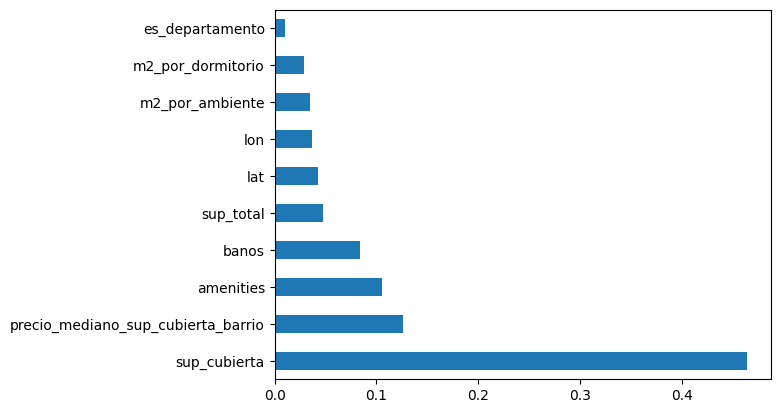

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(reg.feature_importances_, index=X.columns)

# gráfico de barras horizontales
feat_importances.nlargest(10).plot(kind='barh');

# 4. Solución para subir Kaggle

In [ ]:
df_ap = pd.read_csv(f"{DIR}/a_predecir.csv", index_col="id")
df_ap.head(2)

,description,address,lat,lon,publication_date,publisher_id,features,location_0,location_1,location_2,location_3,location_4,operation_type,property_type,source,price,currency_type
id,,,,,,,,,,,,,,,,,
264893,casa construida en 2 plantas. capacidad para ...,"Calle Esmeralda 599, Buenos Aires, Ciudad Autó...",-34.601357,-58.378109,3 nov 2024,NaN,4 dormitorios;4 baños;308 m²;internet;balcón;c...,Argentina,Ciudad Autónoma de Buenos Aires,Buenos Aires,Ciudad Autónoma de Buenos Aires,NaN,venta,casa,properati,NaN,dolares
264899,congreso piso 4 ambientes antiguo reciclado mu...,"República Bolivariana de Venezuela 1699, Monts...",-34.614742,-58.390285,18 nov 2022,NaN,3 dormitorios;3 baños;91 m²;balcón;gas natural...,Argentina,Ciudad Autónoma de Buenos Aires,Montserrat,Ciudad de Buenos Aires,NaN,venta,casa,properati,NaN,dolares


In [ ]:
df_ap.shape

(13471, 17)

In [ ]:
X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

# Entrenamos el modelo con todos los datos de entrenamiento.csv, con los mejores hiperparámetros
n_estimators = 100
max_depth = 20
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

reg.fit(X, y)

RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)

## 4.2. Generación del archivo para Kaggle

In [ ]:
# =============================================================================
# TRANSFORMACIONES EN df_ap (SIN FILTRAR FILAS - HAY QUE PREDECIR TODO)
# =============================================================================

print("="*80)
print("APLICANDO TRANSFORMACIONES A df_ap")
print("="*80)
print(f"Shape inicial df_ap: {df_ap.shape}")

# -----------------------------------------------------------------------------
# 1. HOMOGENEIZAR property_type
# -----------------------------------------------------------------------------
df_ap["property_type"] = df_ap["property_type"].replace({
    "departamentos": "departamento",
    "casas": "casa"
})

# -----------------------------------------------------------------------------
# 2. EXTRACCIÓN DE FEATURES (features + description)
# -----------------------------------------------------------------------------

# Concatenar features + description
texto_ap = (
    df_ap["features"].fillna("").astype(str) + " " +
    df_ap["description"].fillna("").astype(str)
).str.lower()

def extraer_ap(patron):
    return pd.to_numeric(texto_ap.str.extract(patron, expand=False), errors="coerce")

# Dormitorios - MISMO patrón que df_ent
df_ap["dormitorios"] = extraer_ap(
    r"(\d+)\s*(?:dormitorios?|dormi|habitaciones?|habitacion|habitaci|recamaras?|recamara|cuartos?|habs?\.?|bedrooms?)"
)

# Baños - MISMO patrón que df_ent
df_ap["banos"] = extraer_ap(
    r"(\d+)\s*(?:baños?|banos?|baths?|bathrooms?|toilettes?|wc|servicios?)"
)

# Ambientes - MISMO patrón que df_ent
df_ap["ambientes"] = extraer_ap(
    r"(\d+)\s*(?:ambientes?|ambiente|amb\.?|ambs?|rooms?|room|environments?)"
)

# Superficies - MISMO patrón que df_ent
df_ap["sup_total"] = extraer_ap(r"(\d+(?:[.,]\d+)?)\s*m[²2]")
df_ap["sup_cubierta"] = extraer_ap(
    r"(?:superficie\s+)?(?:s?cubiert[oa]s?)\s*:?\s*(\d+(?:[.,]\d+)?)"
)

# Amenities - MISMO patrón que df_ent
amenities = ['pileta', 'piscina', 'gym', 'gimnasio', 'parrilla', 'cochera',
             'balcon', 'terraza', 'seguridad', 'sum']
df_ap["amenities"] = sum(texto_ap.str.contains(rf'\b{a}', regex=True).astype(int)
                         for a in amenities)

print("✅ Features extraídas")

# -----------------------------------------------------------------------------
# 3. LIMPIEZA DE OUTLIERS (REEMPLAZAR por NaN, NO eliminar filas)
# -----------------------------------------------------------------------------

# Placeholders
placeholders = [11111, 111111, 99999, 88888, 77777, 66666, 55555]
for val in placeholders:
    df_ap["sup_cubierta"] = df_ap["sup_cubierta"].replace(val, np.nan)
    df_ap["sup_total"] = df_ap["sup_total"].replace(val, np.nan)

# Ceros
df_ap["sup_cubierta"] = df_ap["sup_cubierta"].replace(0, np.nan)
df_ap["sup_total"] = df_ap["sup_total"].replace(0, np.nan)

# Límites (IGUALES que df_ent, pero reemplazar con NaN en lugar de filtrar filas)
df_ap["sup_cubierta"] = df_ap["sup_cubierta"].where(
    (df_ap["sup_cubierta"] >= 15) & (df_ap["sup_cubierta"] <= 500)
)

df_ap["sup_total"] = df_ap["sup_total"].where(
    (df_ap["sup_total"] >= 20) & (df_ap["sup_total"] <= 800)
)

df_ap["dormitorios"] = df_ap["dormitorios"].where(
    (df_ap["dormitorios"] >= 1) & (df_ap["dormitorios"] <= 6)
)

df_ap["banos"] = df_ap["banos"].where(
    (df_ap["banos"] >= 1) & (df_ap["banos"] <= 5)
)

df_ap["ambientes"] = df_ap["ambientes"].where(
    (df_ap["ambientes"] >= 1) & (df_ap["ambientes"] <= 10)
)

print("✅ Outliers limpiados (reemplazados por NaN)")

# -----------------------------------------------------------------------------
# 4. VARIABLES BINARIAS
# -----------------------------------------------------------------------------
df_ap["es_casa"] = (df_ap["property_type"] == "casa").astype(int)
df_ap["es_departamento"] = (df_ap["property_type"] == "departamento").astype(int)

print("✅ Variables binarias creadas")

# -----------------------------------------------------------------------------
# 5. EXTRACCIÓN DE BARRIO
# -----------------------------------------------------------------------------

valores_genericos = [
    "Capital Federal", "Buenos Aires",
    "Ciudad Autónoma de Buenos Aires", "Ciudad de Buenos Aires",
    "CABA", "None", None
]

def extraer_barrio_ap(row):
    if row["location_2"] not in valores_genericos and pd.notna(row["location_2"]):
        return row["location_2"]
    if row["location_3"] not in valores_genericos and pd.notna(row["location_3"]):
        return row["location_3"]
    return np.nan

df_ap["barrio"] = df_ap.apply(extraer_barrio_ap, axis=1)

print("✅ Barrios extraídos")

# -----------------------------------------------------------------------------
# 6. PRECIO MEDIANO POR BARRIO (mapear usando diccionario de df_ent)
# -----------------------------------------------------------------------------

# Usar el MISMO diccionario barrios_validos que calculaste en df_ent
df_ap["precio_mediano_sup_cubierta_barrio"] = df_ap["barrio"].map(barrios_validos)

print("✅ Precio mediano por barrio mapeado")

# -----------------------------------------------------------------------------
# 7. IMPUTACIÓN CRUZADA (MISMO orden que df_ent)
# -----------------------------------------------------------------------------

# Paso 1: dormitorios ← ambientes - 1
df_ap["dormitorios"] = df_ap["dormitorios"].fillna(df_ap["ambientes"] - 1)

# Paso 2: ambientes ← dormitorios + 1
df_ap["ambientes"] = df_ap["ambientes"].fillna(df_ap["dormitorios"] + 1)

# Paso 3: baños ← 1 baño cada 2 dormitorios (mínimo 1)
df_ap["banos"] = df_ap["banos"].fillna(
    np.maximum(1, (df_ap["dormitorios"] / 2).round())
)

# Paso 4: Fallback mutuo superficies
df_ap["sup_total"] = df_ap["sup_total"].fillna(df_ap["sup_cubierta"])
df_ap["sup_cubierta"] = df_ap["sup_cubierta"].fillna(df_ap["sup_total"])

print("✅ Imputación cruzada completada")

# -----------------------------------------------------------------------------
# 8. IMPUTACIÓN CON MEDIANA (usando MEDIANAS de df_ent)
# -----------------------------------------------------------------------------

# CRÍTICO: Usar las MISMAS medianas que en df_ent, NO recalcular
medianas_df_ent = {
    'dormitorios': imputer.fit(df_ent[['dormitorios']]).statistics_[0],
    'banos': imputer.fit(df_ent[['banos']]).statistics_[0],
    'ambientes': imputer.fit(df_ent[['ambientes']]).statistics_[0],
    'sup_cubierta': imputer.fit(df_ent[['sup_cubierta']]).statistics_[0],
    'sup_total': imputer.fit(df_ent[['sup_total']]).statistics_[0],
    'precio_mediano_sup_cubierta_barrio': imputer.fit(df_ent[['precio_mediano_sup_cubierta_barrio']]).statistics_[0]
}

features_basicas = ['dormitorios', 'banos', 'ambientes', 'sup_cubierta', 'sup_total',
                    'precio_mediano_sup_cubierta_barrio']

for col in features_basicas:
    if df_ap[col].isna().sum() > 0:
        df_ap[col] = df_ap[col].fillna(medianas_df_ent[col])
        print(f"  {col}: imputado con mediana de df_ent ({medianas_df_ent[col]:.1f})")

# Amenities → 0
df_ap["amenities"] = df_ap["amenities"].fillna(0)

print("✅ Imputación con mediana completada")




APLICANDO TRANSFORMACIONES A df_ap
Shape inicial df_ap: (13471, 17)
✅ Features extraídas
✅ Outliers limpiados (reemplazados por NaN)
✅ Variables binarias creadas
✅ Barrios extraídos
✅ Precio mediano por barrio mapeado
✅ Imputación cruzada completada
  dormitorios: imputado con mediana de df_ent (2.0)
  banos: imputado con mediana de df_ent (1.0)
  ambientes: imputado con mediana de df_ent (3.0)
  sup_cubierta: imputado con mediana de df_ent (57.0)
  sup_total: imputado con mediana de df_ent (57.0)
  precio_mediano_sup_cubierta_barrio: imputado con mediana de df_ent (2352.9)
✅ Imputación con mediana completada


In [ ]:
# =============================================================================
# FEATURES DERIVADAS - df_ap
# =============================================================================

print("\n" + "="*80)
print("CREANDO FEATURES DERIVADAS EN df_ap")
print("="*80)

# 1. Crear las features
df_ap["m2_por_dormitorio"] = df_ap["sup_cubierta"] / df_ap["dormitorios"]
df_ap["m2_por_ambiente"] = df_ap["sup_cubierta"] / df_ap["ambientes"]

print(f"\nFeatures creadas:")
print(f"m2_por_dormitorio - NaN: {df_ap['m2_por_dormitorio'].isna().sum()}, "
      f"Inf: {np.isinf(df_ap['m2_por_dormitorio']).sum()}")
print(f"m2_por_ambiente - NaN: {df_ap['m2_por_ambiente'].isna().sum()}, "
      f"Inf: {np.isinf(df_ap['m2_por_ambiente']).sum()}")

# 2. Limpiar infinitos
for col in ["m2_por_dormitorio", "m2_por_ambiente"]:
    df_ap[col] = df_ap[col].replace([np.inf, -np.inf], np.nan)

# 3. Limpiar outliers (MISMOS límites que df_ent)
df_ap["m2_por_dormitorio"] = df_ap["m2_por_dormitorio"].where(
    df_ap["m2_por_dormitorio"] < 500
)

df_ap["m2_por_ambiente"] = df_ap["m2_por_ambiente"].where(
    df_ap["m2_por_ambiente"] < 200
)

print(f"\nDespués de limpiar:")
print(f"m2_por_dormitorio - NaN: {df_ap['m2_por_dormitorio'].isna().sum()}")
print(f"m2_por_ambiente - NaN: {df_ap['m2_por_ambiente'].isna().sum()}")

# 4. Imputar con las MISMAS medianas de df_ent
print(f"\nImputando con medianas de df_ent:")
print(f"  m2_por_dormitorio: {mediana_m2_dorm_ent:.2f}")
print(f"  m2_por_ambiente: {mediana_m2_amb_ent:.2f}")

df_ap["m2_por_dormitorio"] = df_ap["m2_por_dormitorio"].fillna(mediana_m2_dorm_ent)
df_ap["m2_por_ambiente"] = df_ap["m2_por_ambiente"].fillna(mediana_m2_amb_ent)



# Verificar estadísticas
print("\nEstadísticas de df_ap:")
print(f"\nm2_por_dormitorio:")
print(df_ap["m2_por_dormitorio"].describe())
print(f"\nm2_por_ambiente:")
print(df_ap["m2_por_ambiente"].describe())

# Guardar medianas ANTES de select_dtypes
mediana_m2_dorm_ent = df_ent["m2_por_dormitorio"].median()
mediana_m2_amb_ent = df_ent["m2_por_ambiente"].median()

print(f"\n📌 Medianas guardadas para df_ap:")
print(f"  m2_por_dormitorio: {mediana_m2_dorm_ent:.2f}")
print(f"  m2_por_ambiente: {mediana_m2_amb_ent:.2f}")


CREANDO FEATURES DERIVADAS EN df_ap

Features creadas:
m2_por_dormitorio - NaN: 0, Inf: 404
m2_por_ambiente - NaN: 0, Inf: 0

Después de limpiar:
m2_por_dormitorio - NaN: 404
m2_por_ambiente - NaN: 7

Imputando con medianas de df_ent:
  m2_por_dormitorio: 36.50
  m2_por_ambiente: 22.00

Estadísticas de df_ap:

m2_por_dormitorio:
count    13471.000000
mean        41.701612
std         22.318121
min          5.125000
25%         28.500000
50%         38.000000
75%         50.000000
max        363.000000
Name: m2_por_dormitorio, dtype: float64

m2_por_ambiente:
count    13471.000000
mean        26.658472
std         14.982447
min          3.925000
25%         18.333333
50%         23.333333
75%         31.000000
max        196.000000
Name: m2_por_ambiente, dtype: float64

📌 Medianas guardadas para df_ap:
  m2_por_dormitorio: 36.50
  m2_por_ambiente: 22.00


In [ ]:
# TODO: Hacer en df_ap la misma limpieza que en df_ent
df_ap = df_ap.fillna(0)
df_ap = df_ap.select_dtypes('number')

X_ap = df_ap[X.columns]

# Predecimos los precios del dataset a predecir
y_pred_ap = reg.predict(X_ap)
y_pred_ap

array([572350.        , 226692.1210101 , 373031.74      , ...,
       129160.6713658 , 180628.8575838 , 231812.89398622])

In [ ]:
# =============================================================================
# REDONDEO ESTILO REAL ESTATE - VERSIÓN SIMPLE
# =============================================================================

# Predecir normalmente
y_pred_ap = reg.predict(X_ap)

print(f"Total de predicciones: {len(y_pred_ap)}")

# Redondeo simple con X9,900
def redondear_simple(precio):
    redondeado = np.round(precio / 5000) * 5000
    umbrales = [100000, 150000, 200000, 250000, 300000, 350000, 400000,
                450000, 500000, 600000, 700000, 800000, 900000, 1000000]
    for umbral in umbrales:
        if redondeado >= umbral and redondeado <= umbral + 5000:
            return umbral - 100
    return redondeado

y_pred_simple = np.array([redondear_simple(p) for p in y_pred_ap])

# Verificar algunos ejemplos (máximo 10, o los que haya)
print("="*80)
print("EJEMPLOS DE REDONDEO")
print("="*80)
print(f"\n{'Original':>15s} {'Redondeado':>15s}")
print("-" * 35)

n_ejemplos = min(10, len(y_pred_ap))
for i in range(n_ejemplos):
    print(f"${y_pred_ap[i]:>13,.2f} ${y_pred_simple[i]:>13,.0f}")

# Guardar
df_ap_submission = pd.read_csv(f"{DIR}/a_predecir.csv", index_col="id")
df_ap_submission["price"] = y_pred_simple
df_ap_submission[["price"]].to_csv(f"{DIR}/Entrega 3/Florencia Montagna V10 - Features Derivadas.csv")

print(f"\n✅ Archivo guardado con {len(y_pred_simple)} predicciones")

IndexError: list index out of range

In [ ]:
# =============================================================================
# REDONDEO ESTILO REAL ESTATE - VERSIÓN SIMPLE
# =============================================================================

# Predecir normalmente
y_pred_ap = reg.predict(X_ap)

# Redondeo simple con X9,900
def redondear_simple(precio):
    redondeado = np.round(precio / 5000) * 5000
    umbrales = [100000, 150000, 200000, 250000, 300000, 350000, 400000,
                450000, 500000, 600000, 700000, 800000, 900000, 1000000]
    for umbral in umbrales:
        if redondeado >= umbral and redondeado <= umbral + 5000:
            return umbral - 100
    return redondeado

y_pred_simple = np.array([redondear_simple(p) for p in y_pred_ap])

# Verificar algunos ejemplos
print("="*80)
print("EJEMPLOS DE REDONDEO")
print("="*80)
print(f"\n{'Original':>15s} {'Redondeado':>15s}")
print("-" * 35)

for i in range(10):
    print(f"${y_pred_ap[i]:>13,.2f} ${y_pred_simple[i]:>13,.0f}")

# Guardar
df_ap_submission = pd.read_csv(f"{DIR}/a_predecir.csv", index_col="id")
df_ap_submission["price"] = y_pred_simple
df_ap_submission[["price"]].to_csv(f"{DIR}/Entrega 3/Florencia Montagna V10 - Features Derivadas.csv")

print("\n✅ Archivo guardado: Florencia Montagna V10 - Features Derivadas.csv")

IndexError: list index out of range

In [ ]:
# =============================================================================
# REDONDEO ESTILO REAL ESTATE - PROBAR 3 VERSIONES
# =============================================================================

# Predecir normalmente
y_pred_ap = reg.predict(X_ap)

# --- VERSIÓN 1: Miles simples (baseline) ---
y_pred_miles = np.round(y_pred_ap / 1000) * 1000

# --- VERSIÓN 2: Redondeo simple con X9,900 ---
def redondear_simple(precio):
    redondeado = np.round(precio / 5000) * 5000
    umbrales = [100000, 150000, 200000, 250000, 300000, 350000, 400000,
                450000, 500000, 600000, 700000, 800000, 900000, 1000000]
    for umbral in umbrales:
        if redondeado >= umbral and redondeado <= umbral + 5000:
            return umbral - 100
    return redondeado

y_pred_simple = np.array([redondear_simple(p) for p in y_pred_ap])



# Comparar las 2 versiones
print("="*80)
print("COMPARACIÓN DE ESTRATEGIAS DE REDONDEO")
print("="*80)
print(f"\n{'Original':>15s} {'Miles':>15s} {'Simple':>15s}")
print("-" * 65)

for i in range(15):
    print(f"${y_pred_ap[i]:>13,.2f} ${y_pred_miles[i]:>13,.0f} "
          f"${y_pred_simple[i]:>13,.0f}")

# Guardar las 3 versiones
df_ap_submission = pd.read_csv(f"{DIR}/a_predecir.csv", index_col="id")


# Versión 2: Simple
df_ap_submission["price"] = y_pred_simple
df_ap_submission[["price"]].to_csv(f"{DIR}/Entrega 3/Florencia Montagna V10 - Simple.csv")



IndexError: list index out of range

# 5. Análisis de los errores

In [ ]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# cambiar estos valores de hiperparámetros por los optimizados
n_estimators = 200
max_depth = 30

reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)
_ = reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

KeyboardInterrupt: 

In [ ]:
X_test["error"] = abs(y_pred - y_test)
X_test["price"] = y_test
X_test["pred_price"] = y_pred
X_test.sort_values(by="error", ascending=False)
X_test.head()